In [3]:
from pathlib import Path

In [6]:
DATA_DIR = Path("../data")

classes = [
    "Buffalo", 
    "Camel", 
    "Horse", 
    "Pig", 
    "Cat", 
    "Donkey", 
    "Sheep", 
    "Chicken", 
    "Goat"
]

In [7]:
splits = ["train", "test", "validation"]

for split in splits:
    print(f"\n{split.upper()}")
    print("-" * 30)

    for class_name in classes:
        class_path = DATA_DIR / split / class_name

        if class_path.exists():
            images = [
                p for p in class_path.iterdir()
                if p.is_file()
            ]
            print(f"{class_name:10s}: {len(images)}")
        else:
            print(f"{class_name:10s}: FOLDER NOT FOUND")


TRAIN
------------------------------
Buffalo   : 371
Camel     : 401
Horse     : 975
Pig       : 644
Cat       : 611
Donkey    : 773
Sheep     : 692
Chicken   : 387
Goat      : 743

TEST
------------------------------
Buffalo   : 371
Camel     : 401
Horse     : 278
Pig       : 183
Cat       : 613
Donkey    : 221
Sheep     : 196
Chicken   : 389
Goat      : 212

VALIDATION
------------------------------
Buffalo   : 371
Camel     : 401
Horse     : 140
Pig       : 91
Cat       : 611
Donkey    : 110
Sheep     : 99
Chicken   : 387
Goat      : 107


## Check for corrupted/unsupported images

In [8]:
from PIL import Image

for split in splits:
    print(f"\n{split.upper()}")
    print("-" * 30)

    corrupted_images = []

    for class_name in classes:
        class_path = DATA_DIR / split / class_name

        for image_path in class_path.iterdir():
            if image_path.is_file():
                try:
                    with Image.open(image_path) as img:
                        img.verify()
                except Exception:
                    corrupted_images.append(str(image_path))

print("Corrupted Images:", len(corrupted_images))


TRAIN
------------------------------

TEST
------------------------------

VALIDATION
------------------------------
Corrupted Images: 0


## Checking the image formats

In [9]:
from collections import Counter

In [ ]:
for split in splits:
    formats = Counter()

    for class_name in classes:
        class_path = DATA_DIR / split / class_name

        for image_path in class_path.iterdir():
            if image_path.is_file():
                formats[image_path.suffix.lower()] += 1 #e.g. -> suffixs = .jpg, .png | lower -> if .JPG = .jpg

    print(f"\n{split.upper()}")
    print("-" * 30)

    for extension, count in formats.items():
        print(f"{extension}: {count}")


TRAIN
------------------------------
.jpg: 5314
.png: 34
.webp: 1
.jpeg: 248

TEST
------------------------------
.jpg: 2764
.png: 21
.webp: 3
.jpeg: 76

VALIDATION
------------------------------
.jpg: 2279
.png: 12
.jpeg: 26


## Checking the images' dimensions and color channels

In [12]:
from PIL import ImageSequence
from collections import Counter

In [16]:
for split in splits:
    sizes = Counter()
    modes = Counter()

    for class_name in classes:
        class_path = DATA_DIR / split / class_name

        #Skip if folder does not exist
        if not class_path.exists():
            continue

        for image_path in class_path.iterdir():
            if image_path.is_file():
                try:
                    with Image.open(image_path) as img:
                        sizes[img.size] += 1
                        modes[img.mode] += 1
                except Exception:
                    pass
    print(f"\n{split.upper()}")
    print("-" * 30)

    print("Total analyzed images:", sum(sizes.values()))
    print("Unique image sizes:", len(sizes))

    print("\nMost common sizes:")
    for size, count in sizes.most_common(10):
        print(f"{size}: {count}")

    print("\nImage modes:")
    for mode, count in modes.items():
        print(f"{mode}: {count}")


TRAIN
------------------------------
Total analyzed images: 5597
Unique image sizes: 1420

Most common sizes:
(256, 256): 1808
(500, 333): 327
(500, 750): 221
(500, 375): 131
(1024, 768): 100
(640, 447): 83
(612, 408): 68
(1024, 683): 65
(275, 183): 53
(1000, 667): 49

Image modes:
RGB: 5557
RGBA: 23
CMYK: 4
L: 7
P: 6

TEST
------------------------------
Total analyzed images: 2864
Unique image sizes: 862

Most common sizes:
(256, 256): 959
(500, 333): 144
(500, 375): 131
(1024, 768): 100
(500, 750): 78
(375, 500): 34
(1024, 683): 33
(612, 408): 28
(640, 447): 25
(768, 1024): 20

Image modes:
RGB: 2844
L: 7
P: 6
RGBA: 7

VALIDATION
------------------------------
Total analyzed images: 2317
Unique image sizes: 656

Most common sizes:
(256, 256): 659
(500, 333): 180
(500, 375): 142
(1024, 768): 107
(500, 750): 78
(1024, 683): 47
(375, 500): 45
(500, 667): 27
(768, 1024): 18
(4000, 6000): 18

Image modes:
RGB: 2309
RGBA: 7
P: 1


## Visual Inspection

In [17]:
import matplotlib.pyplot as plt
import random

In [19]:
random.seed(42)

class_name = "Horse"
class_path = DATA_DIR / "train" / "Horse"

image_paths = [
    p for p in class_path.iterdir()
    if p.is_file()
]

sample_paths = random.sample(image_paths, min(9, len(image_paths)))


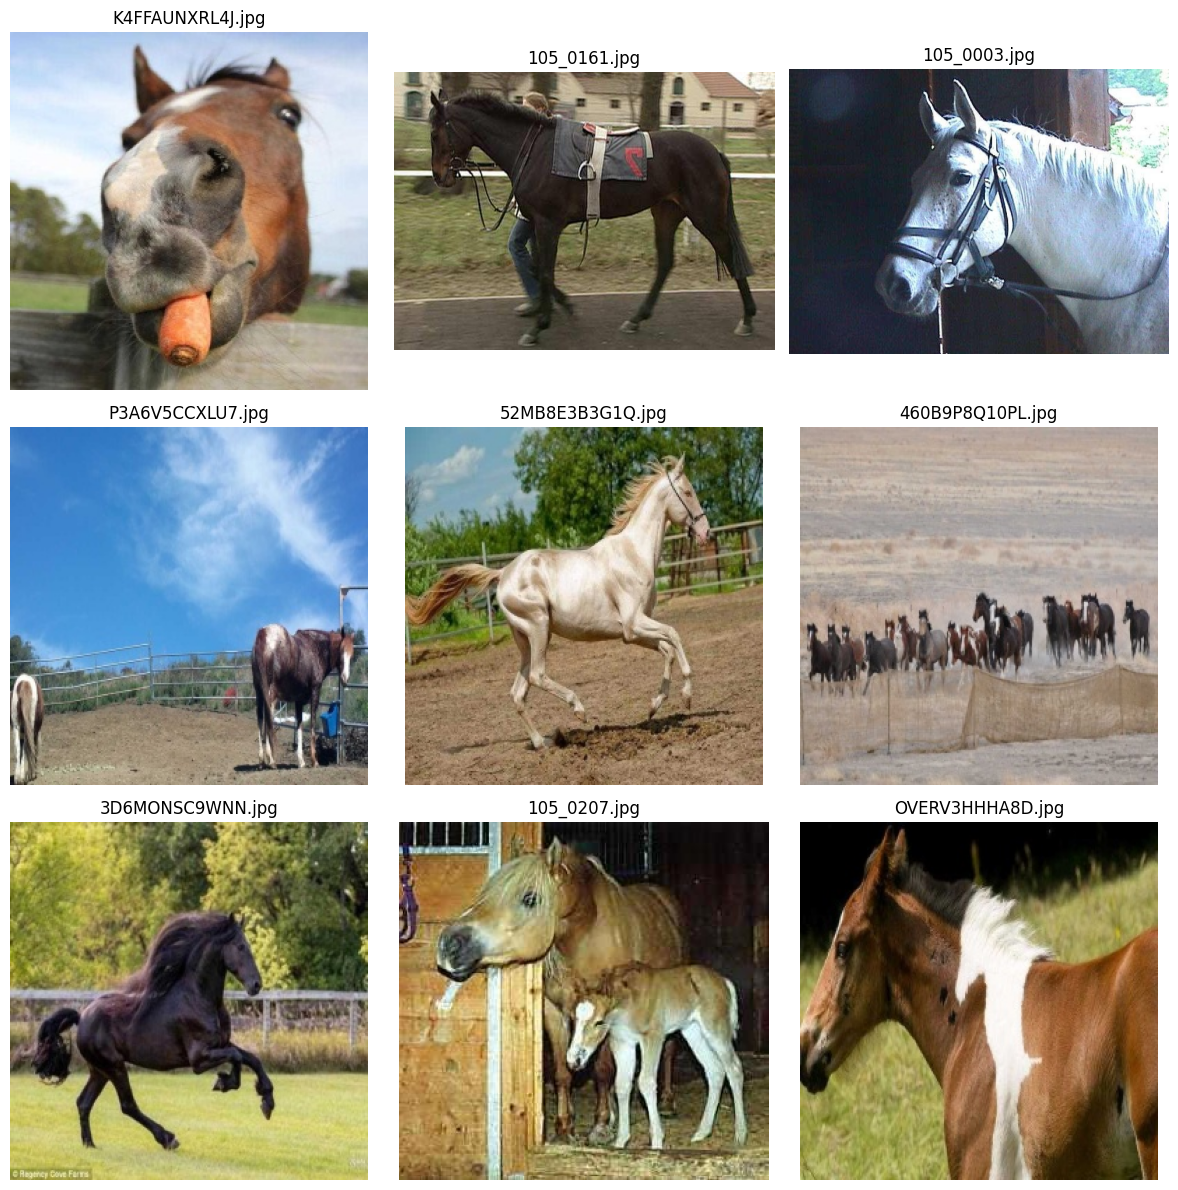

In [20]:
plt.figure(figsize=(12, 12))

for i, image_path in enumerate(sample_paths):
    image = Image.open(image_path).convert("RGB")

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

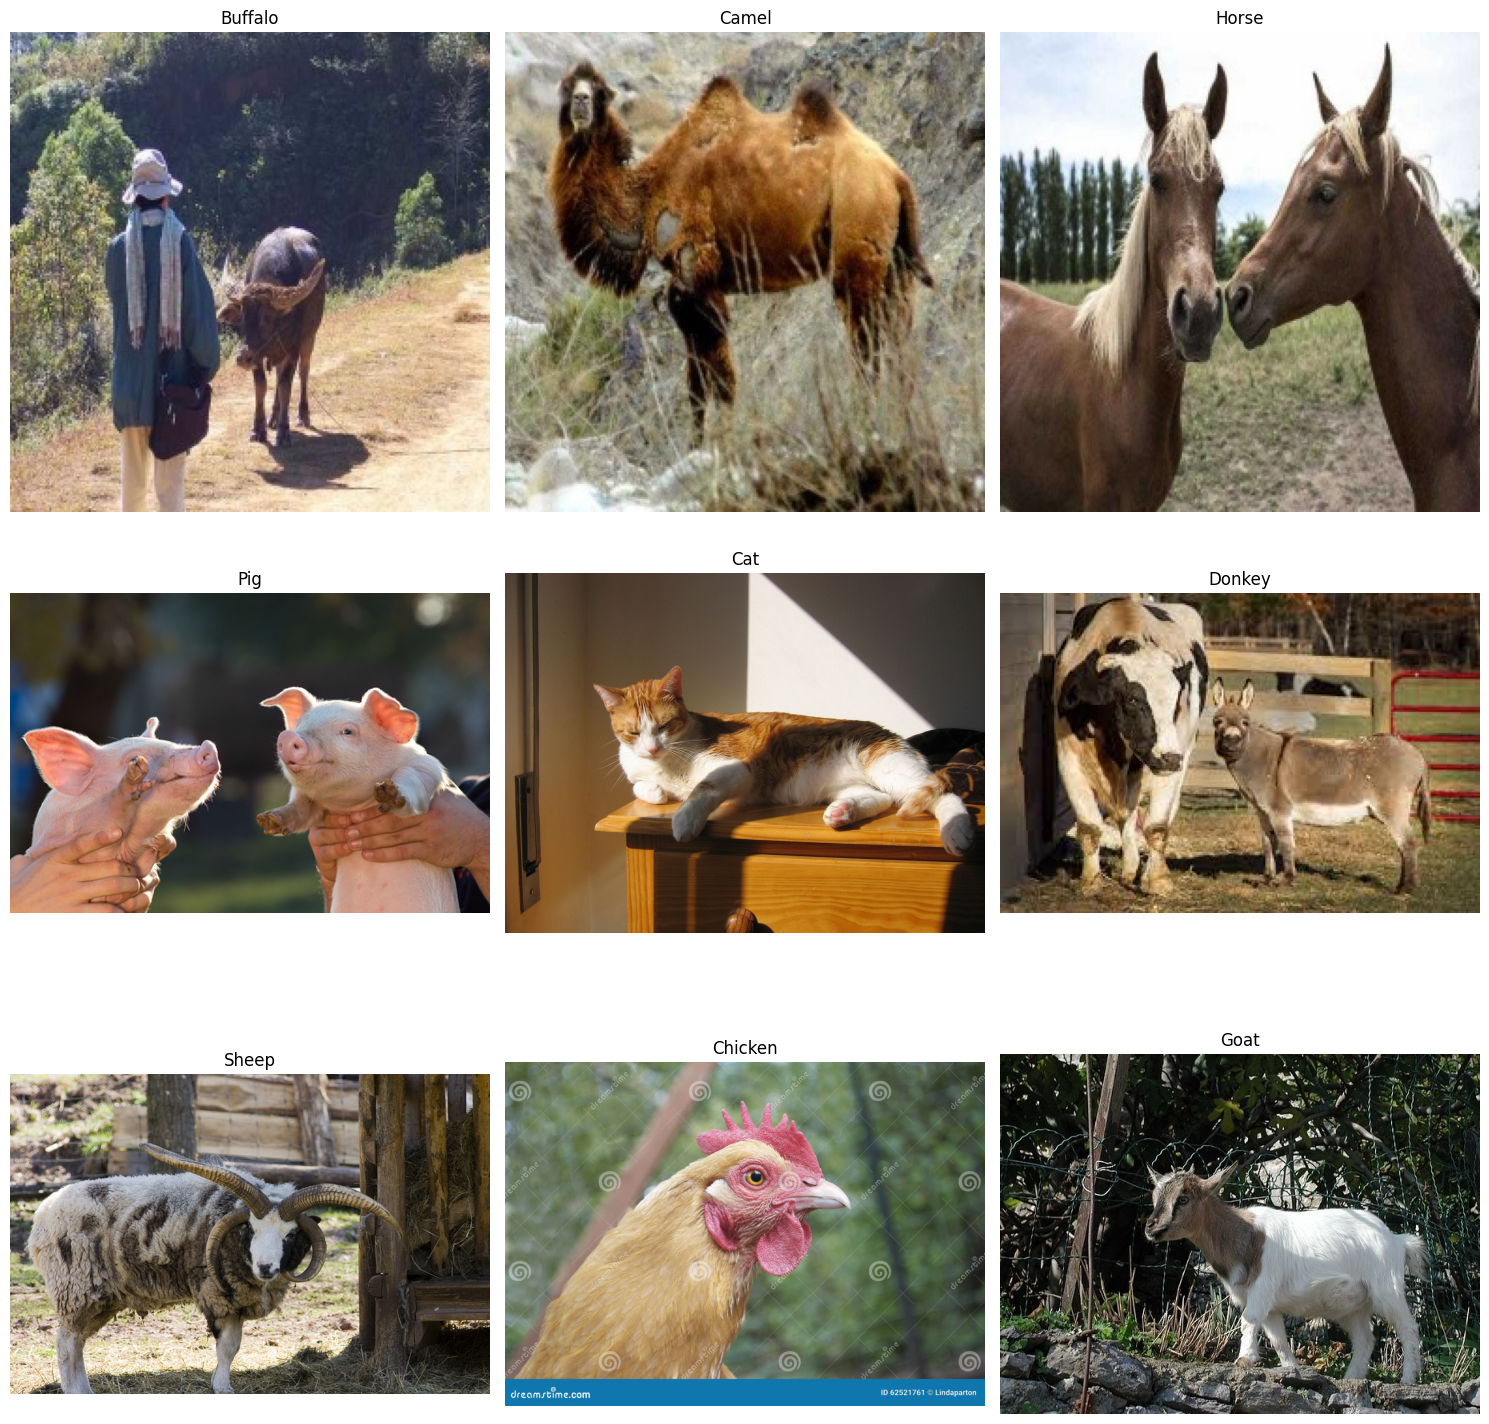

In [21]:
class_folders = [
    "Buffalo",
    "Camel",
    "Horse",
    "Pig",
    "Cat",
    "Donkey",
    "Sheep",
    "Chicken",
    "Goat"
]

plt.figure(figsize=(15, 15))

for i, class_name in enumerate(class_folders):

    class_path = DATA_DIR / "train" / class_name

    image_paths = [
        p for p in class_path.iterdir()
        if p.is_file()
    ]

    image_path = random.choice(image_paths)

    image = Image.open(image_path).convert("RGB")

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()